In [117]:
# All libs we need.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from matplotlib.patches import Rectangle


### Data preparation ###

In [118]:
# Load IRIS dataset
iris = load_iris()
samples = iris.data
labels = iris.target
names = iris.target_names


samples_train, samples_test, labels_train, labels_test = train_test_split(
    samples,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels  # Preserve class distribution across splits
)

# Check split sizes
print("Training set size:", samples_train.shape)
print("Testing set size: ", samples_test.shape)

petal_lengths = samples_train[:, 2]
petal_widths = samples_train[:, 3]


Training set size: (105, 4)
Testing set size:  (45, 4)


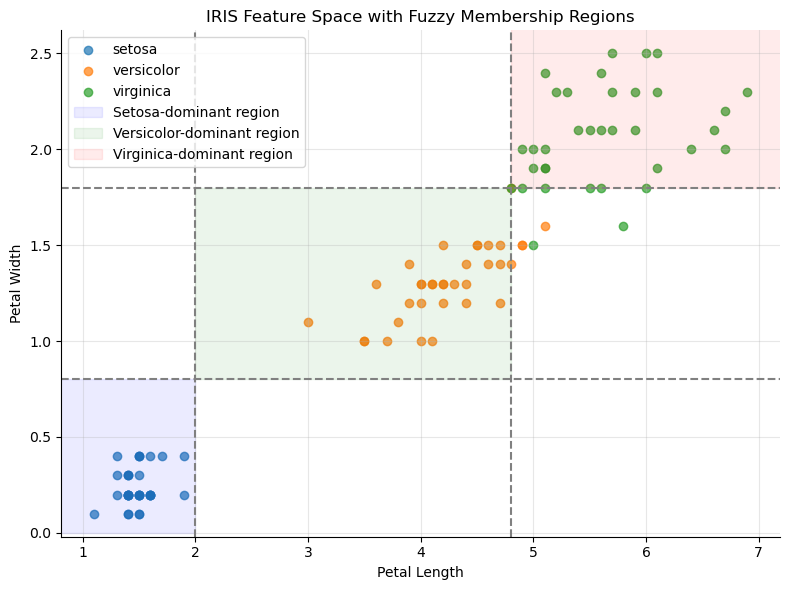

In [119]:

fig, ax = plt.subplots(figsize=(8, 6))

# -------- Scatter plot (data) --------
for i, label in enumerate(names):
    idx = (labels_train == i)
    ax.scatter(
        petal_lengths[idx],
        petal_widths[idx],
        label=label,
        alpha=0.7
    )

# -------- Fuzzy region boundaries (dashed lines) --------
ax.axvline(2.0, color='gray', linestyle='--')
ax.axvline(4.8, color='gray', linestyle='--')

ax.axhline(0.8, color='gray', linestyle='--')
ax.axhline(1.8, color='gray', linestyle='--')

# -------- Highlight dominant fuzzy regions --------
# Setosa region (small, narrow)
ax.add_patch(
    Rectangle(
        (0.0, 0.0), 2.0, 0.8,
        color='blue', alpha=0.08, label='Setosa-dominant region'
    )
)

# Versicolor region (medium, medium)
ax.add_patch(
    Rectangle(
        (2.0, 0.8), 2.8, 1.0,
        color='green', alpha=0.08, label='Versicolor-dominant region'
    )
)

# Virginica region (large, wide)
ax.add_patch(
    Rectangle(
        (4.8, 1.8), 3.0, 1.2,
        color='red', alpha=0.08, label='Virginica-dominant region'
    )
)

# -------- Labels & style --------
ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
ax.set_title("IRIS Feature Space with Fuzzy Membership Regions")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [120]:
# =========================
# Feature statistics for membership design
# =========================

feature_names = ["petal_length", "petal_width"]

for i, feature in enumerate([petal_lengths, petal_widths]):
    print("=" * 60)
    print(f"Feature: {feature_names[i]}")
    
    for class_id, class_name in enumerate(names):
        values = feature[labels_train == class_id]
        
        print(f"\nClass: {class_name}")
        print(f"  Min: {np.min(values):.2f}")
        print(f"  5% percentile: {np.percentile(values, 5):.2f}")
        print(f"  25% percentile: {np.percentile(values, 25):.2f}")
        print(f"  Median: {np.median(values):.2f}")
        print(f"  75% percentile: {np.percentile(values, 75):.2f}")
        print(f"  95% percentile: {np.percentile(values, 95):.2f}")
        print(f"  Max: {np.max(values):.2f}")


Feature: petal_length

Class: setosa
  Min: 1.10
  5% percentile: 1.30
  25% percentile: 1.40
  Median: 1.50
  75% percentile: 1.55
  95% percentile: 1.76
  Max: 1.90

Class: versicolor
  Min: 3.00
  5% percentile: 3.50
  25% percentile: 4.00
  Median: 4.20
  75% percentile: 4.60
  95% percentile: 4.90
  Max: 5.10

Class: virginica
  Min: 4.80
  5% percentile: 4.90
  25% percentile: 5.10
  Median: 5.60
  75% percentile: 6.00
  95% percentile: 6.70
  Max: 6.90
Feature: petal_width

Class: setosa
  Min: 0.10
  5% percentile: 0.10
  25% percentile: 0.20
  Median: 0.20
  75% percentile: 0.30
  95% percentile: 0.40
  Max: 0.40

Class: versicolor
  Min: 1.00
  5% percentile: 1.00
  25% percentile: 1.20
  Median: 1.30
  75% percentile: 1.45
  95% percentile: 1.53
  Max: 1.80

Class: virginica
  Min: 1.50
  5% percentile: 1.74
  25% percentile: 1.90
  Median: 2.10
  75% percentile: 2.30
  95% percentile: 2.50
  Max: 2.50


In [121]:
# Make some functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)
    
    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_membership_func(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def interp_membership(domain, mf_values, x):
    """
    Equivalent to skfuzzy.interp_membership
    domain: e.g. np.linspace(...)
    mf_values: membership values on that domain
    x: crisp input
    """
    return np.interp(x, domain, mf_values)

def centroid_defuzzification(domain, aggregated_mf):
    """
    Compute centroid defuzzification (discrete version).

    domain: np.ndarray
        The universe of discourse (e.g., domain_difficulty)
    aggregated_mf: np.ndarray
        Aggregated membership values over the domain

    returns: float
        Crisp output (centroid)
    """
    numerator = np.sum(domain * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        # no rule fired → fallback (should rarely happen)
        return np.mean(domain)

    return numerator / denominator



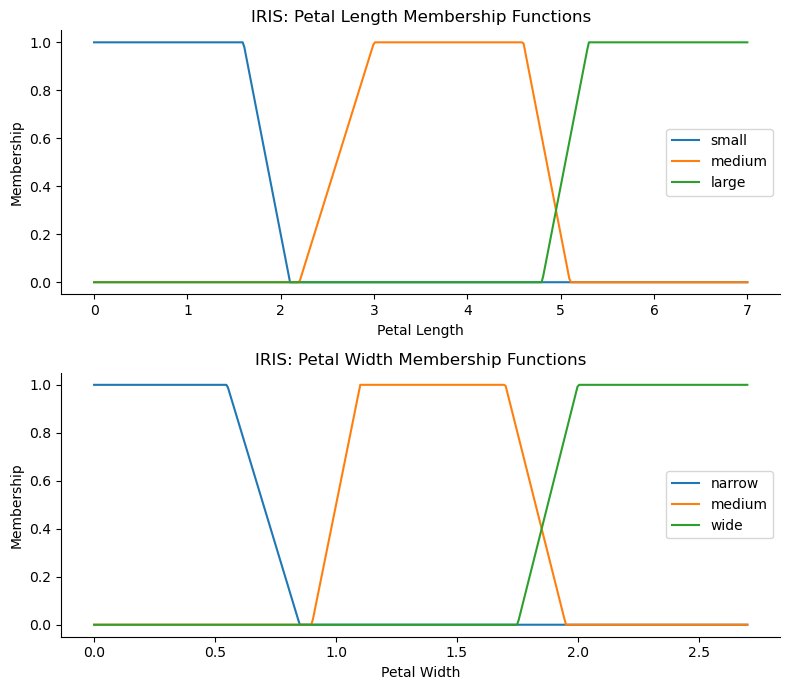

In [122]:
# ---------------------------
# IRIS Domains (petal features)
# ---------------------------
domain_petal_length = np.linspace(0.0, 7.0, 401)   # IRIS petal length approx [1, 7]
domain_petal_width  = np.linspace(0.0, 2.7, 401)   # IRIS petal width  approx [0.1, 2.5+]

# Petal Length (recommended: trapezoids)
pLength_small  = trapezoidal_membership_function(domain_petal_length, 0.0, 0.0, 1.6, 2.1)
pLength_medium = trapezoidal_membership_function(domain_petal_length, 2.2, 3.0, 4.6, 5.1)
pLength_large  = trapezoidal_membership_function(domain_petal_length, 4.8, 5.3, 7.0, 7.0)

# Petal Width (recommended: trapezoids)
pWidth_narrow = trapezoidal_membership_function(domain_petal_width, 0.0, 0.0, 0.55, 0.85)
pWidth_medium = trapezoidal_membership_function(domain_petal_width, 0.9, 1.1, 1.7, 1.95)
pWidth_wide   = trapezoidal_membership_function(domain_petal_width, 1.75, 2.0, 2.7, 2.7)

# # ---------------------------
# # Petal Length Memberships
# # small / medium / large
# # ---------------------------
# pLength_small  = trapezoidal_membership_function(domain_petal_length, 0.0, 0.0, 1.6, 2.1)
# pLength_medium = gauss_membership_func(domain_petal_length, c=3.8, sigma=0.55)
# pLength_large  = trapezoidal_membership_function(domain_petal_length, 4.6, 4.9, 7.0, 7.0)

# # ---------------------------
# # Petal Width Memberships
# # narrow / medium / wide
# # ---------------------------
# pWidth_narrow = trapezoidal_membership_function(domain_petal_width, 0.0, 0.0, 0.55, 0.85)
# pWidth_medium = gauss_membership_func(domain_petal_width, c=1.30, sigma=0.28)
# pWidth_wide   = trapezoidal_membership_function(domain_petal_width, 1.75, 1.95, 2.7, 2.7)

# ---------------------------
# Plot memberships
# ---------------------------
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(8, 7))

# Petal length
ax0.plot(domain_petal_length, pLength_small,  linewidth=1.5, label='small')
ax0.plot(domain_petal_length, pLength_medium, linewidth=1.5, label='medium')
ax0.plot(domain_petal_length, pLength_large,  linewidth=1.5, label='large')
ax0.set_title("IRIS: Petal Length Membership Functions")
ax0.set_xlabel("Petal Length")
ax0.set_ylabel("Membership")
ax0.legend()

# Petal width
ax1.plot(domain_petal_width, pWidth_narrow, linewidth=1.5, label='narrow')
ax1.plot(domain_petal_width, pWidth_medium, linewidth=1.5, label='medium')
ax1.plot(domain_petal_width, pWidth_wide,   linewidth=1.5, label='wide')
ax1.set_title("IRIS: Petal Width Membership Functions")
ax1.set_xlabel("Petal Width")
ax1.set_ylabel("Membership")
ax1.legend()

for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Rule: ###
- R1: IF petal_length is small                 
THEN class is setosa
- R2: IF petal_length is medium AND petal_width is medium 
THEN class is versicolor
- R3: IF petal_length is large  AND petal_width is wide  
THEN class is virginica


In [123]:
# ---------------------------
# Output domain (class axis)
# ---------------------------
domain_class = np.linspace(0.0, 1.0, 501)

out_setosa     = trapezoidal_membership_function(domain_class, 0.0, 0.0, 0.25, 0.40)
out_versicolor = trapezoidal_membership_function(domain_class, 0.30, 0.45, 0.55, 0.70)
out_virginica  = trapezoidal_membership_function(domain_class, 0.60, 0.75, 1.00, 1.00)


This function do 2 things:
1. fuzzification. Convert the real data values into the membership value of each fuzzy set.
2. Firing the rules. Use the min membership value of the antecedent clauses to chop off the consequent membership function.
3. Aggregation: The chopoff result are aggregated(We can choose Max aggregation or summation aggregation). 

In [124]:
def iris_rule_inference(petal_length_value, petal_width_value, aggregation="max"):
    """
    Fuzzy rule inference for one IRIS sample.
    """

    # -------------------
    # Fuzzification
    # -------------------
    pl_small_firing  = interp_membership(domain_petal_length, pLength_small,  petal_length_value)
    pl_medium_firing = interp_membership(domain_petal_length, pLength_medium, petal_length_value)
    pl_large_firing  = interp_membership(domain_petal_length, pLength_large,  petal_length_value)

    pw_medium_firing = interp_membership(domain_petal_width,  pWidth_medium, petal_width_value)
    pw_wide_firing   = interp_membership(domain_petal_width,  pWidth_wide,   petal_width_value)

    # -------------------
    # Rule firing (AND = min)
    # -------------------
    rule1_activation = pl_small_firing                          # R1 → setosa
    rule2_activation = min(pl_medium_firing, pw_medium_firing)     # R2 → versicolor
    rule3_activation = min(pl_large_firing, pw_wide_firing)        # R3 → virginica

    # -------------------
    # Implication (clipping)
    # -------------------
    chopoff1 = np.minimum(out_setosa,     rule1_activation)
    chopoff2 = np.minimum(out_versicolor, rule2_activation)
    chopoff3 = np.minimum(out_virginica,  rule3_activation)

    # -------------------
    # Aggregation
    # -------------------
    if aggregation == "max":
        aggregated_output = np.maximum.reduce([
            chopoff1, chopoff2, chopoff3
        ])
    elif aggregation == "sum":
        aggregated_output = np.sum([
            chopoff1, chopoff2, chopoff3
        ], axis=0)
    else:
        raise ValueError("aggregation must be 'max' or 'sum'")

    return aggregated_output, (rule1_activation, rule2_activation, rule3_activation)



This is the classifier. We use the aggregated output to determine which class we should assign the sample.

In [125]:
def iris_classify(petal_length_value, petal_width_value, aggregation="max"):
    aggregated_output, (r1, r2, r3) = iris_rule_inference(
        petal_length_value, petal_width_value, aggregation
    )

    # Defuzzification
    crisp = centroid_defuzzification(domain_class, aggregated_output)

    # Map crisp value to class via membership
    mu_setosa     = interp_membership(domain_class, out_setosa,     crisp)
    mu_versicolor = interp_membership(domain_class, out_versicolor, crisp)
    mu_virginica  = interp_membership(domain_class, out_virginica,  crisp)

    scores = np.array([mu_setosa, mu_versicolor, mu_virginica])
    pred_class = int(np.argmax(scores))  # 0=setosa, 1=versicolor, 2=virginica

    return pred_class, crisp, scores, (r1, r2, r3)


In [126]:
# test points
tests = [
    (1.5, 0.3),   # typical setosa
    (4.0, 1.3),   # typical versicolor
    (6.0, 2.0)    # typical virginica
]

for plv, pwv in tests:
    pred, crisp, scores, rules = iris_classify(plv, pwv)
    print(f"\nInput (pl={plv}, pw={pwv})")
    print("Predicted class:", iris.target_names[pred])
    print("Crisp value:", crisp)
    print("Class scores [setosa, versicolor, virginica]:", scores)
    print("Rule firing [R1, R2, R3]:", rules)



Input (pl=1.5, pw=0.3)
Predicted class: setosa
Crisp value: 0.1648752556237219
Class scores [setosa, versicolor, virginica]: [1. 0. 0.]
Rule firing [R1, R2, R3]: (1.0, 0.0, 0.0)

Input (pl=4.0, pw=1.3)
Predicted class: versicolor
Crisp value: 0.5000000000000001
Class scores [setosa, versicolor, virginica]: [0. 1. 0.]
Rule firing [R1, R2, R3]: (0.0, 1.0, 0.0)

Input (pl=6.0, pw=2.0)
Predicted class: virginica
Crisp value: 0.8349504592582855
Class scores [setosa, versicolor, virginica]: [0. 0. 1.]
Rule firing [R1, R2, R3]: (0.0, 0.0, 0.9943703703703708)


In [127]:

# ---------------------------
# Run classification for test_samples
# ---------------------------
y_pred = []

petal_lengths_test = samples_test[:, 2]
petal_widths_test  = samples_test[:, 3]


for petal_length, petal_width in zip(petal_lengths_test, petal_widths_test):
    pred_class, crisp, scores, rule_firing = iris_classify(
        petal_length, petal_width, aggregation="max"
    )
    y_pred.append(pred_class)

y_pred = np.array(y_pred)

# for petal_length, petal_width in zip(petal_lengths, petal_widths):
#     pred_class, crisp, scores, rule_firing = iris_classify(
#         petal_length, petal_width, aggregation="max"
#     )
#     y_pred.append(pred_class)

# y_pred = np.array(y_pred)


# ---------------------------
# Compute accuracy
# ---------------------------
accuracy = np.mean(y_pred == labels_test)

print("IRIS FLS Classification Accuracy:")
print(f"Accuracy = {accuracy:.4f}")

IRIS FLS Classification Accuracy:
Accuracy = 0.8889


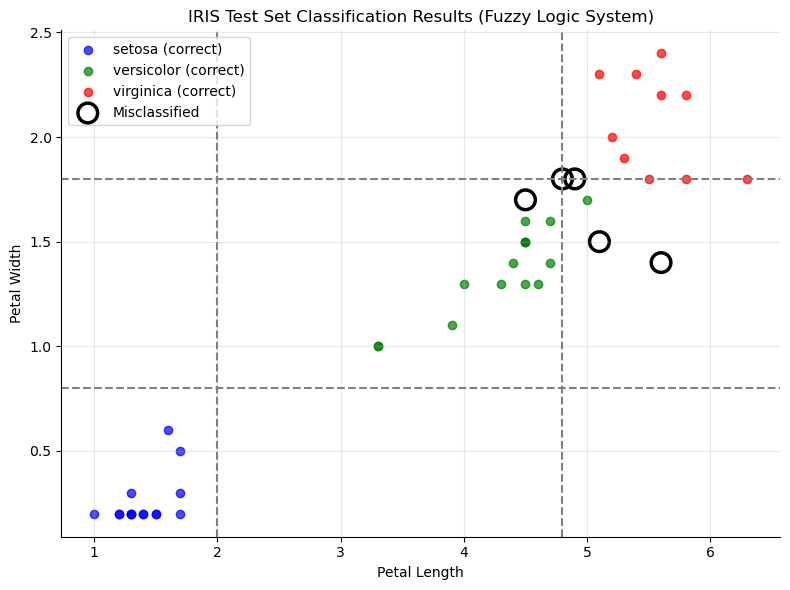

In [128]:
# =========================
# Visualization of test set classification results
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Extract test features
petal_length_test = samples_test[:, 2]
petal_width_test  = samples_test[:, 3]

# Identify correctly and incorrectly classified samples
correct = (y_pred == labels_test)
incorrect = ~correct

# Color map for classes
colors = ['blue', 'green', 'red']

plt.figure(figsize=(8, 6))

# -------- Plot correctly classified samples --------
for class_id, class_name in enumerate(names):
    idx = (labels_test == class_id) & correct
    plt.scatter(
        petal_length_test[idx],
        petal_width_test[idx],
        color=colors[class_id],
        label=f"{class_name} (correct)",
        alpha=0.7,
        marker='o'
    )

# -------- Plot misclassified samples --------
plt.scatter(
    petal_length_test[incorrect],
    petal_width_test[incorrect],
    facecolors='none',
    edgecolors='black',
    linewidths=2.5,
    marker='o',
    s=200,
    label="Misclassified"
)

# -------- Plot fuzzy region boundaries (same as before) --------
plt.axvline(2.0, color='gray', linestyle='--')
plt.axvline(4.8, color='gray', linestyle='--')
plt.axhline(0.8, color='gray', linestyle='--')
plt.axhline(1.8, color='gray', linestyle='--')

# -------- Labels & style --------
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("IRIS Test Set Classification Results (Fuzzy Logic System)")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
